# Major Project - PCA HMM for Regime Classification


This version is going to look at training on a given time series then looking at the likelihood of the testing series being possible given the train series. 

Chose the training set to include the 2020 COVID crash out of curiosity and to follow the methods of the paper. 

Percentage change of the data is taken as oppose to raw end of day pricing since that is genrally considered a statinary time series which allows PCA to be used. 

Train series: 2019-01-01 -> 2024-12-31

Test series: 2025-01-01 -> 2026-03-29

In [1]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import scipy.stats as stats

from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import cross_val_score, TimeSeriesSplit 

from hmmlearn import hmm

seed = 123
random.seed(seed)

In [ ]:
tickers = ["XLK","XLV","XLF","XLY","XLC","XLI","XLP","XLE","XLU","XLRE","XLB","^VIX", "^SPX"]
sector_data = yf.download(tickers, start="2019-01-01", end='2026-03-29', auto_adjust = False)["Adj Close"]
returns = sector_data.pct_change().dropna()

[*********************100%***********************]  13 of 13 completed


Now split into the training and testing sets

In [3]:
cut_date = "2025-01-01"

test_data = returns[returns.index >= cut_date]
train_data = returns[returns.index < cut_date]

test_data.shape, train_data.shape


((309, 13), (1509, 13))

In [4]:
scaler = StandardScaler()

train_scaled = pd.DataFrame(
    scaler.fit_transform(train_data), 
    columns = returns.columns
)

In [5]:
test_scaled = pd.DataFrame(
    scaler.transform(test_data), 
    columns = returns.columns
    )

In [6]:
pca = PCA(n_components=3, random_state=seed)

latent_train = pca.fit_transform(train_data)

latent_test = pca.transform(test_data)

latent_test.shape, latent_train.shape

((309, 3), (1509, 3))

In [7]:
Saved_PC = ["PC1", 'PC2', "PC3"]
df_loadings = pd.DataFrame(
    pca.components_, 
    columns = returns.columns, 
    index = Saved_PC 
)
df_loadings.head()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
PC1,-0.110093,-0.112513,-0.119422,-0.118724,-0.109772,-0.138610,-0.063051,-0.094030,-0.066895,-0.078948,-0.124906,-0.112212,0.929453
PC2,0.289180,0.208321,0.406817,0.321216,0.288294,0.229844,0.180758,0.294909,0.266637,0.189425,0.235695,0.239314,0.359041
PC3,0.042360,-0.264235,0.795228,0.115010,0.043761,-0.325031,-0.130688,-0.186727,-0.160369,-0.129163,-0.241175,-0.140988,-0.053107


In this case it looks like we're more strongly predicting the bearish case in PC1 as opposed to the last script where we were looking in the direction of the bullish

In [8]:
pca.explained_variance_ratio_

array([0.82256447, 0.09578834, 0.03077929])

### Setting up the HMM Model

Choosing two hidden states and not initializing the transition matrix or inital probabilities 

In [9]:
hmm_model = hmm.GaussianHMM(n_components=2, random_state=seed)

#### Checking the metrics of model by doing CV on the Latent Test Data 

This would help be able to tell the stability of the loglikleihood esitmate on the training set as well as the stability of the state means and transition matrix 

We should see a trend that the log likelihood increases than converge after enough data is seen since the trend is assumed stationary. Deviaiton in that trend could be due to the unnderlying data that is used in each respective split since outliers will be harder to fit. 

1. Split data -> time series split in scikit learn 
2. Fit the model on a component of the training data -> training set of the training set 
3. Evaluate the model on the other part of the training set that was not used for the training 
4. Compute the state means, transition matrix and the normalized log lieklihood estimate 

In [10]:
tscv = TimeSeriesSplit(n_splits = 10)

In [11]:
state_means = []
trans_matrx = []
scores = []

for train_idx, val_idx in tscv.split(latent_train):
    tr = latent_train[train_idx]
    val = latent_train[val_idx]

    hmm_model.fit(tr)

    scores.append(hmm_model.score(val)/len(val))
    trans_matrx.append(hmm_model.transmat_)
    state_means.append(hmm_model.means_)


Model is not converging.  Current: 1015.2626215117898 is not greater than 1015.5797332913374. Delta is -0.3171117795476448
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 2000.0192037494442 is not greater than 2000.5207044895217. Delta is -0.5015007400775175
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
E

In [37]:
state_zero_is_bull = []
rows = []
for i, sm in enumerate(state_means): 
    if sm[0][0] < 0: 
        state_zero_is_bull.append(True)
        bull_means = sm[0]
        
        bull_to_bear = trans_matrx[i][0][1]
        bull_to_bull = trans_matrx[i][0][0]

        bear_to_bull = trans_matrx[i][1][0]
        bear_to_bear = trans_matrx[i][1][1]

        bear_means = sm[1]
        
    else:
        state_zero_is_bull.append(False)
        bull_means = sm[1] 

        bull_to_bear = trans_matrx[i][1][0]
        bull_to_bull = trans_matrx[i][1][1]

        bear_to_bull = trans_matrx[i][0][1]
        bear_to_bear = trans_matrx[i][0][0]

        
        bear_means = sm[0]
        

    row = {

        ('bull', 'PC1'): bull_means[0],
        ('bull', 'PC2'): bull_means[1], 
        ('bull', 'PC3'): bull_means[2], 

        ('bull', 'to_bull'): bull_to_bull,
        ('bull', 'to_bear'): bull_to_bear,

        ('bear', 'PC1'): bear_means[0],
        ('bear', 'PC2'): bear_means[1], 
        ('bear', 'PC3'): bear_means[2],


        ('bear', 'to_bear'): bear_to_bear,
        ('bear', 'to_bull'): bear_to_bull, 

        ('val_set', 'Norm_LogLikelihood'):np.round(scores[i], decimals=3)

        
    }
    rows.append(row)

In [38]:
cv_results = pd.DataFrame(rows)
cv_results.columns = pd.MultiIndex.from_tuples(cv_results.columns)
cv_results.index.name = 'CV_fold'
cv_results.index = cv_results.index + 1

cv_results

bull                                              bear            \
              PC1       PC2       PC3   to_bull   to_bear       PC1       PC2   
CV_fold                                                                         
1       -0.014287 -0.000908 -0.000626  0.959760  0.040240  0.125433  0.019854   
2       -0.019629 -0.002006 -0.000814  0.890481  0.109519  0.113665  0.016971   
3       -0.009800  0.000103 -0.001310  0.961403  0.038597  0.052694  0.002070   
4       -0.009041  0.000651 -0.000619  0.959609  0.040391  0.054743  0.003695   
5       -0.008308  0.000408 -0.000711  0.962643  0.037357  0.055044  0.004198   
6       -0.007392  0.000418 -0.000003  0.968182  0.031818  0.061480  0.004999   
7       -0.009009  0.000029  0.000305  0.949755  0.050245  0.054988  0.001495   
8       -0.008665 -0.000494  0.000297  0.948695  0.051305  0.053472  0.002444   
9       -0.008283 -0.000720  0.000249  0.950217  0.049783  0.050739  0.002840   
10      -0.007797 -0.000627  0.000101  0.951588  0.048412  0.046798  0.002667   

                                                 val_set  
              PC3   to_bear   to_bull Norm_LogLikelihood  
CV_fold                                                   
1       -0.004201  0.285880  0.714120              6.889  
2       -0.003875  0.258005  0.741995              1.512  
3       -0.003455  0.801342  0.198658              5.203  
4       -0.001159  0.754576  0.245424              6.377  
5       -0.001270  0.742200  0.257800              6.079  
6       -0.001354  0.736658  0.263342              5.165  
7        0.000225  0.713987  0.286013              6.231  
8       -0.000759  0.679772  0.320228              6.862  
9       -0.000438  0.675115  0.324885              7.161  
10      -0.000028  0.681190  0.318810              6.380

In [42]:
columns_of_interest = [('bull', 'PC1'), ('bear', 'PC1'), ('val_set', 'Norm_LogLikelihood')]

cv_summary = pd.DataFrame({
    'median': cv_results[columns_of_interest].median(), 
    'q05': cv_results[columns_of_interest].quantile(0.05), 
    'q95': cv_results[columns_of_interest].quantile(0.95)
})
cv_summary

,,median,q05,q95
bull,PC1,-0.008837,-0.017225,-0.007574
bear,PC1,0.054866,0.048572,0.120137
val_set,Norm_LogLikelihood,6.304000,3.155850,7.038600


Text(0.5, 1.0, 'Model Stability - CV Log-Likelihood Analysis')

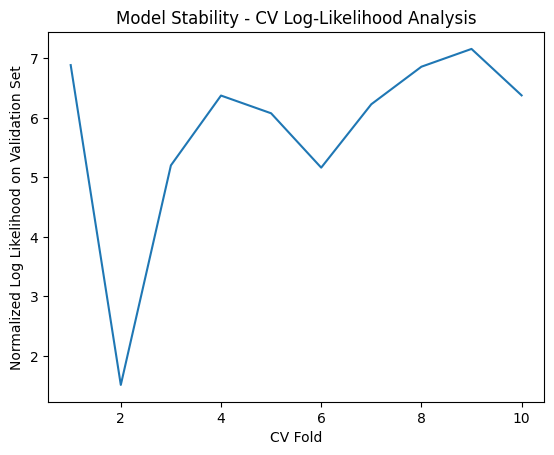

In [44]:
plt.plot(cv_results.index,cv_results[('val_set', 'Norm_LogLikelihood')])
plt.xlabel("CV Fold")
plt.ylabel("Normalized Log Likelihood on Validation Set")
plt.title("Model Stability - CV Log-Likelihood Analysis")

#### Moving onto just fitting all of the training data 

In [48]:
hmm_model.fit(latent_train)

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


,n_components,2
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,123


#### Analysis of the state means

State Means => Mean of the features under a given state 

In this case it is the mean in the PCA space, so to actually get intuition out of the state mean you need to look at the loadings of the PC's
   

In [49]:
df_means = pd.DataFrame(
    hmm_model.means_,
    columns = Saved_PC,
)
df_means

,PC1,PC2,PC3
0,0.053181,0.004639,-0.000047
1,-0.008028,-0.000700,0.000007


Results show that PC1 has a positive contribution (VIX high and SPX returns low -> Bearish state  = 0)

#### Transition Matrix for the Model - Based on full training set

Given we know that state 0 is likely the bearish state we can get a better interpretation of the transition matrix. 

For the transition matrix here the diagonal enrties represent the probability of staying in the bearish (0,0) and bullish (1,1) states given you are already there. 

We see a high probability that once you are in a bullish regime you will stay there. 


In [50]:
transition_matrix = hmm_model.transmat_
transition_matrix

array([[0.6488474 , 0.3511526 ],
       [0.05228686, 0.94771314]])

#### Check Gaussian Model Assumption

To check the normality assumption we have to look at the distribution of latent variables values with given hidden state predictions. 

X_t (latent variable) | Z_t (states) = Normal


In [51]:
train_states = hmm_model.predict(latent_train)
X_bear = latent_train[train_states == 0]
X_bull = latent_train[train_states == 1]
X_bear.shape, X_bull.shape

((163, 3), (1346, 3))

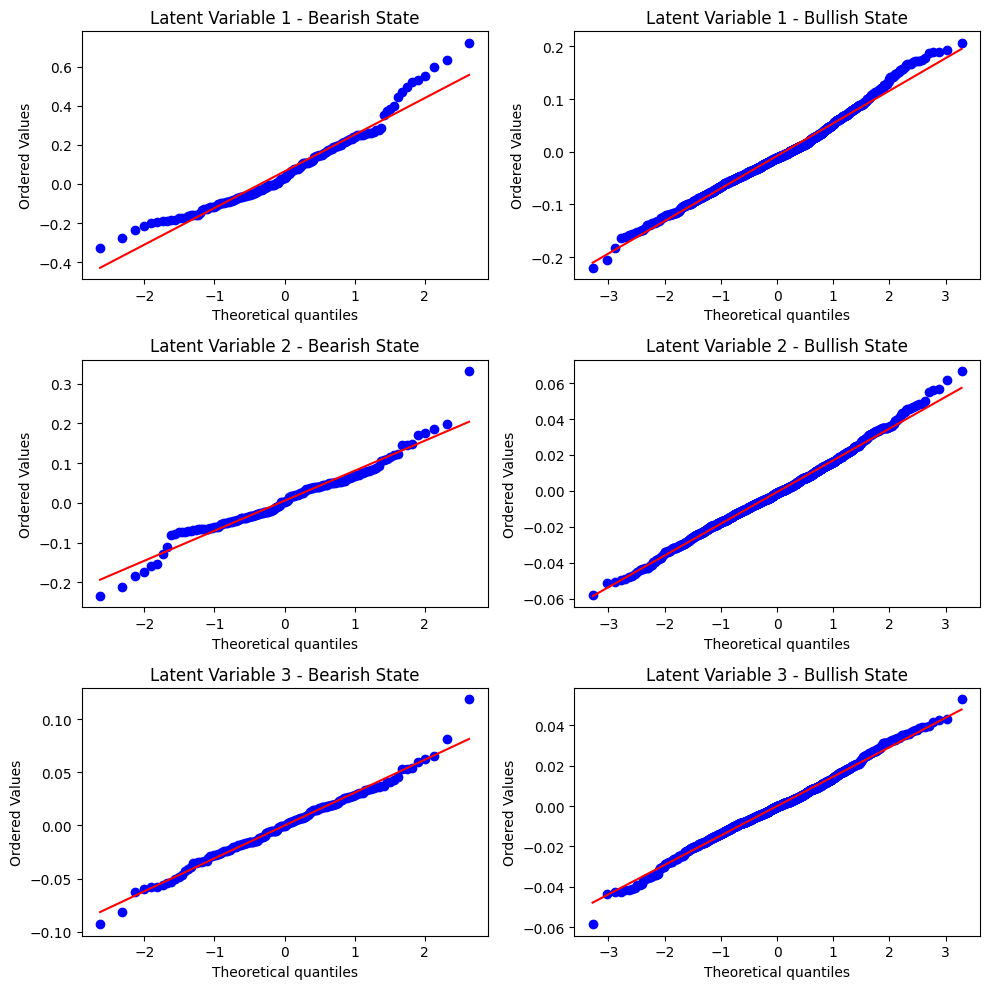

In [52]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,10))
for i in range(X_bear.shape[1]):
    
    stats.probplot(X_bear[:, i], dist='norm', plot=axes[i,0])
    axes[i,0].set_title(f'Latent Variable {i+1} - Bearish State')
    
    stats.probplot(X_bull[:, i], dist='norm', plot=axes[i,1])
    axes[i,1].set_title(f'Latent Variable {i+1} - Bullish State')

plt.tight_layout()
plt.show()

Result show mostly agreement between the theoretical quantiles and ordered values which indicates that the Gaussian model was a proper choice for this data. The slight skew in the top left can be explained by heavy tails in the distribution which is expected in the bearish state as there are far fewer data points (outliers get amplified).

## Analysis on the Log-Likelihood of the 

This score is the probability of seeing the data given the model and its parameters. Positive values are fine since we are using a continuous Guassian model for the emission probabilities, meaning they are probability density functions not discrete probabilities and can therefore take valeus greater than 1. 

Have to normalize to the length of data since the loglikelihood is just a sum of loglikelihood over the entire sequence so naturally longer sequences will have a greater score. 

In [53]:
train_score = np.round(hmm_model.score(latent_train), decimals=3)
print(f'Log-Likelihood of Training Data: {train_score}')

Log-Likelihood of Training Data: 9427.63


In [54]:
print(f'Normalized Log-Lieklihood of Training Data: {np.round(train_score/len(train_data), decimals=4)}')

Normalized Log-Lieklihood of Training Data: 6.2476


In [55]:
test_score = np.round(hmm_model.score(latent_test), decimals=3)

print(f"Log-Lkelihood of the Test Data: {test_score}")

Log-Lkelihood of the Test Data: 2045.632


In [56]:
print(f'Normalized Log-Likelihood of Testing Data: {np.round(train_score/len(train_data), decimals=4)}')

Normalized Log-Likelihood of Testing Data: 6.2476


As we can see the training and testing normalized log likelihoods are roughly equivalent. This is a sign that the model is not overfit to the training data and that the model's parameters are actually quite good for the time series data. 

A slight increase in the testing log likelihood could be explained by less extreme values in the testing set as opposed to the training set. As outliers are harder to model this would lead to low log-likelihoods for these observations. 

We can quickly see that in the standard deviation of the training set is much greater (~5x) that of the testing set for the PC1 latent variables. Given PC1 latent variabels have the greatest state mean contribution for each state more volatility in this component would elad to worse log-likelihoods. 

For this specific data set a prime example owuld be the fact that 2020 financial crisis appears in the training set but ntohing comparable occurs in the testing set. This data ould be very hard to model thus resulting in low log-likelihood for those observaiton whihc would bring down the average LLH in the training set.

In [57]:
np.round(np.std(latent_train[0]),decimals=5), np.round(np.std(latent_test[0]), decimals=5)

(np.float64(0.05877), np.float64(0.01171))

### Plotting of the predicted states for the training and testing data

In [58]:
probs_test = pd.Series(hmm_model.predict(latent_test), index = test_data.index)

probs_train = pd.Series(hmm_model.predict(latent_train), index = train_data.index)

Text(0, 0.5, 'Daily % Returns')

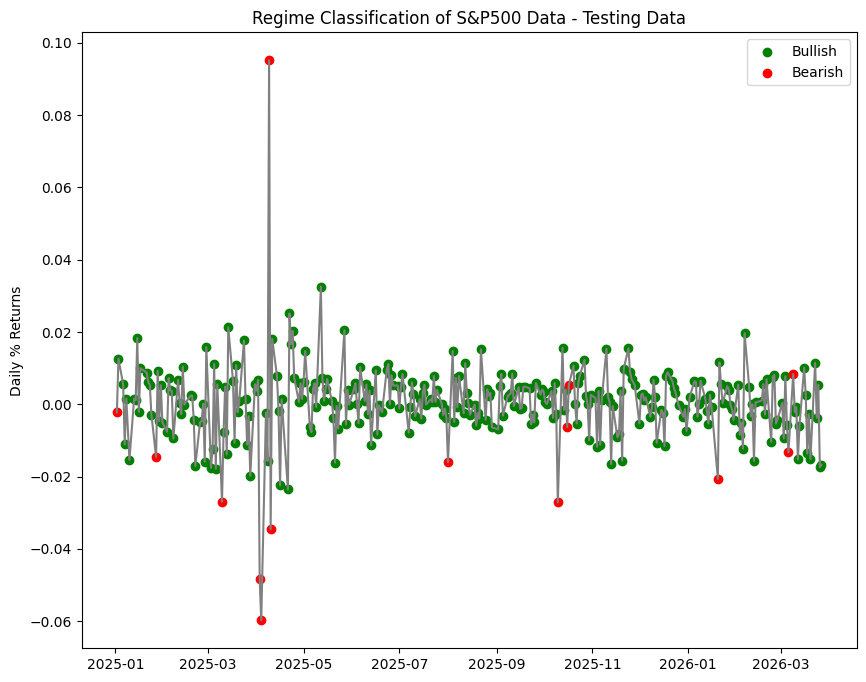

In [59]:
plt.figure(figsize=(10,8))
plt.plot(test_data['^SPX'], color='gray')
plt.scatter(test_data.index[probs_test == 1], test_data['^SPX'][probs_test == 1], color='green', label = 'Bullish')
plt.scatter(test_data.index[probs_test == 0], test_data['^SPX'][probs_test == 0], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data - Testing Data")
plt.legend()
plt.ylabel("Daily % Returns")

Text(0, 0.5, 'Daily % Returns')

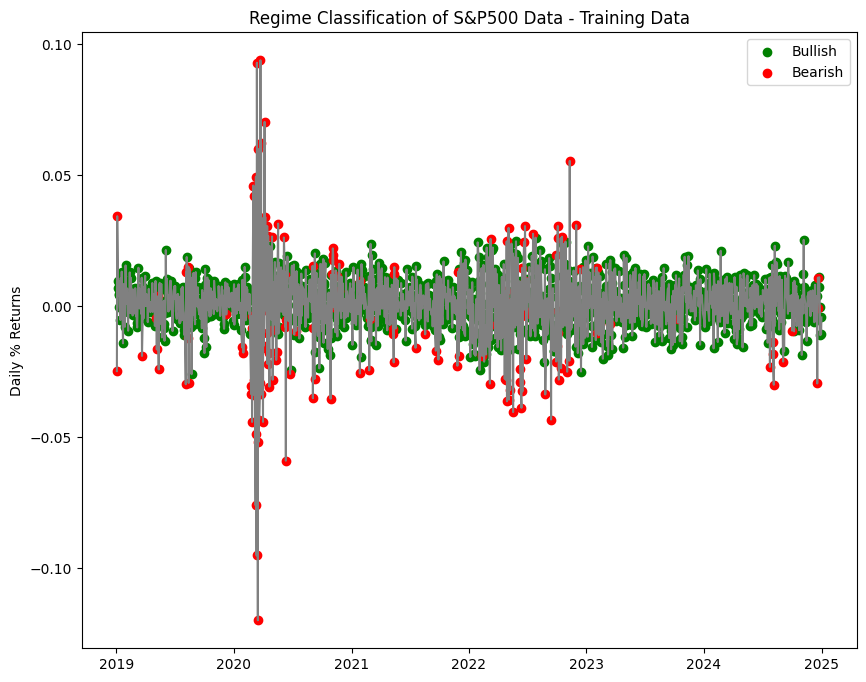

In [60]:
plt.figure(figsize=(10,8))
plt.plot(train_data['^SPX'], color='gray')
plt.scatter(train_data.index[probs_train == 1], train_data['^SPX'][probs_train  == 1], color='green', label = 'Bullish')
plt.scatter(train_data.index[probs_train  == 0], train_data['^SPX'][probs_train  == 0], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data - Training Data")
plt.legend()
plt.ylabel("Daily % Returns")

### Look at the returns!

In [69]:
bull_mean_return = np.mean(train_data['^SPX'][probs_train  == 1]) *100 

print(f'Mean SPX return for states identified as Bullish (training set): {np.round(bull_mean_return, decimals=4)}%')

Mean SPX return for states identified as Bullish (training set): 0.1361%


In [68]:
bear_mean_return = np.mean(train_data['^SPX'][probs_train  == 0]) * 100


print(f'Mean SPX return for states identified as Bearish (training set): {np.round(bear_mean_return, decimals=4)}%')

Mean SPX return for states identified as Bearish (training set): -0.5262%
